## A1 — Utility Functions: `make_W` and `run_reservoir`

These helper functions allow us to build different types of weight matrices and run the autonomous (undriven) reservoir dynamics.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg


# ─────────────────────────────────────────────────────────────
# Weight matrix factory
# kind options:
#   'gaussian'    – W_ij ~ N(0, J²/N)  → spectral radius ≈ J by Marchenko-Pastur
#   'full'        – all entries = J/N
#   'erdos_renyi' – random sparse graph, each edge has weight J/k
#   'data'        – use a provided connectivity matrix D, scaled by J
# ─────────────────────────────────────────────────────────────
def make_W(kind, N, J=1., p=None, D=None, rng=None, dtype=np.float32):
    rng = np.random.default_rng(rng)
    if kind == "gaussian":
        # Entries ~ N(0, J²/N) → by random matrix theory the spectral
        # radius converges to J as N → ∞ (circular law)
        return rng.normal(0, J / np.sqrt(N), (N, N)).astype(dtype)
    if kind == "full":
        return np.full((N, N), J / N, dtype=dtype)
    if kind == "erdos_renyi":
        if p is None:
            raise ValueError("need p")
        k = max(p * N, 1)          # expected degree
        return ((rng.random((N, N)) < p) * (J / k)).astype(dtype)
    if kind == "data":
        if D is None:
            raise ValueError("need D")
        return (J * np.asarray(D, dtype=dtype))
    raise ValueError("kind must be 'gaussian', 'full', 'erdos_renyi', or 'data'")


# ─────────────────────────────────────────────────────────────
# Initial state factory
# ─────────────────────────────────────────────────────────────
def init_r(N, kind="uniform", scale=1., rng=None, dtype=np.float32):
    rng = np.random.default_rng(rng)
    if kind == "uniform":  return rng.uniform(-scale, scale, N).astype(dtype)
    if kind == "gaussian": return rng.normal(0, scale, N).astype(dtype)
    if kind == "zeros":    return np.zeros(N, dtype=dtype)
    if kind == "ones":     return np.ones(N, dtype=dtype)
    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")


# ─────────────────────────────────────────────────────────────
# Run the AUTONOMOUS reservoir (no external input)
#   dr/dt = -r + tanh(W r)   integrated with Euler step eps
# Returns M evenly-spaced snapshots of the N-dim state vector
# ─────────────────────────────────────────────────────────────
def run_reservoir(W, t, N=None, eps=1e-2, M=100, rng=None,
                  init="uniform", init_scale=1., dtype=np.float32):
    W = np.asarray(W, dtype=dtype)
    N = W.shape[0] if N is None else N
    steps = max(1, round(t / eps))
    if not (1 <= M <= steps):
        raise ValueError("need 1 <= M <= round(t/eps)")
    r    = init_r(N, kind=init, scale=init_scale, rng=rng, dtype=dtype)
    take = np.linspace(0, steps - 1, M, dtype=int)
    out, j = np.empty((M, N), dtype=dtype), 0
    for i in range(steps):
        r += eps * (-r + np.tanh(W @ r))
        if i == take[j]:
            out[j] = r
            j += 1
            if j == M:
                break
    return out

Utility functions loaded.


## A2 — Quick sanity check: autonomous reservoir dynamics

Before adding input, we verify the reservoir settles into rich dynamics (not silent, not exploding).
We use a Gaussian W with spectral radius J = 1.2 (slightly above the edge of chaos at J = 1).

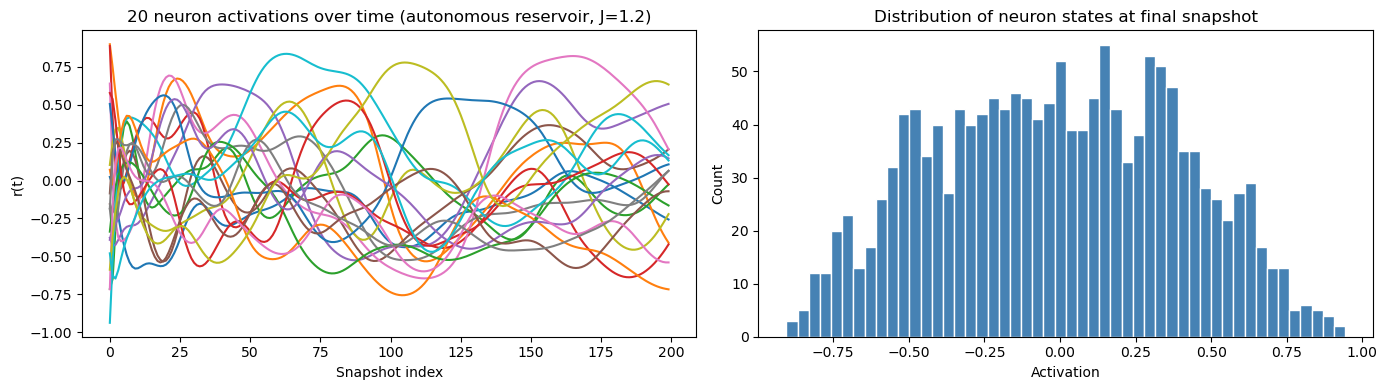

In [2]:
# Build a 1500-neuron Gaussian reservoir with J=1.2
W_test = make_W("gaussian", N=1500, J=1.2, rng=0)

# Run for t=100 time units, collect 200 snapshots
samples = run_reservoir(W_test, t=100.0, eps=1e-2, M=200, rng=1,
                        init="uniform", init_scale=1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 20 random neuron traces over time
axes[0].plot(samples[:, :20])
axes[0].set_title("20 neuron activations over time (autonomous reservoir, J=1.2)")
axes[0].set_xlabel("Snapshot index")
axes[0].set_ylabel("r(t)")

# Distribution of final activations
axes[1].hist(samples[-1], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title("Distribution of neuron states at final snapshot")
axes[1].set_xlabel("Activation")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## A3 — Generate the Lorenz Attractor

The Lorenz system will serve as both the **input signal** (driving the reservoir) and the **prediction target**.

Standard parameters: σ=10, ρ=28, β=8/3 → chaotic regime.

Lorenz data shape: (6000, 3)  (timesteps × dimensions)


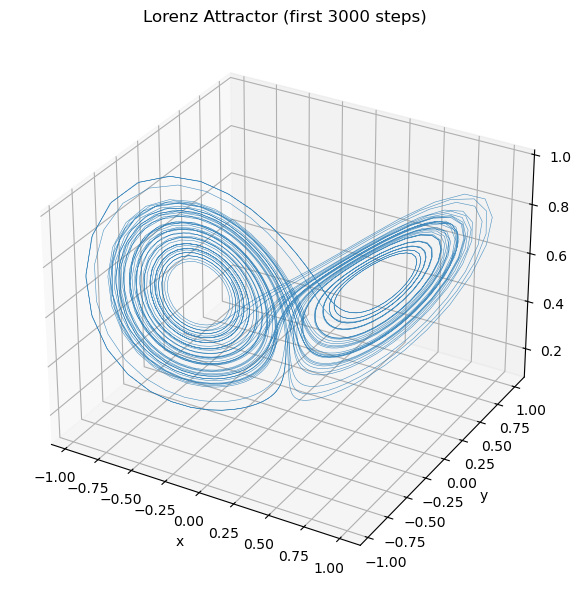

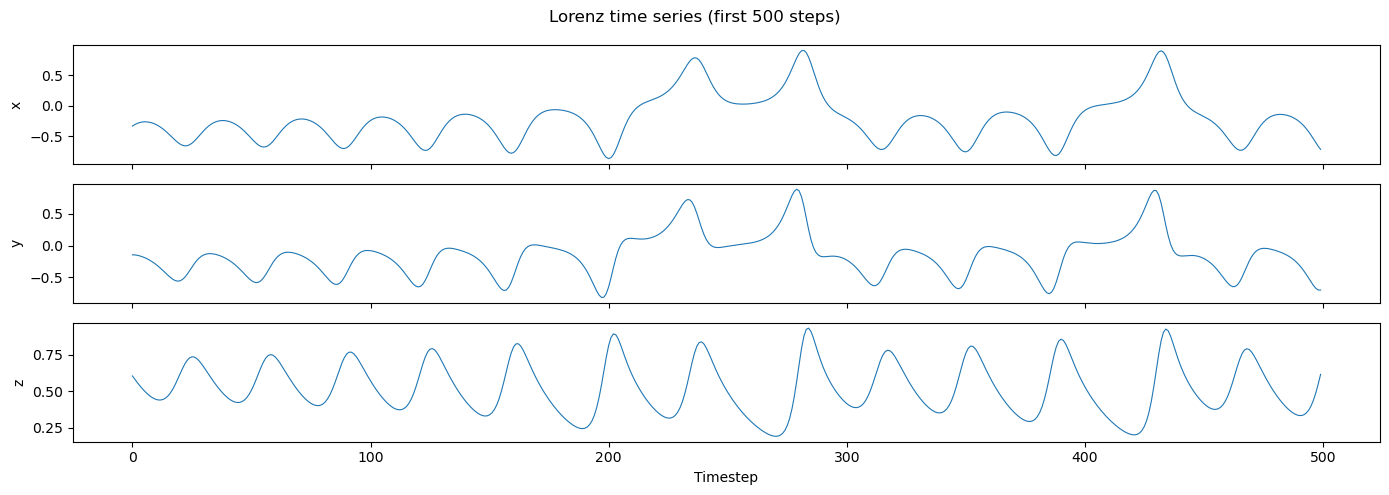

In [3]:
def lorenz(xyz, sigma=10., rho=28., beta=8./3.):
    """Return (dx/dt, dy/dt, dz/dt) given current state xyz."""
    x, y, z = xyz
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])

def generate_lorenz(T, dt=0.02, warmup=500, x0=(0., 1., 1.05)):
    """
    Integrate the Lorenz system using RK4.
    - T      : number of timesteps to KEEP (after warmup)
    - dt     : integration timestep
    - warmup : steps discarded at the start (let it reach the attractor)
    Returns array of shape (T, 3): columns are x, y, z.
    """
    total = T + warmup
    traj  = np.zeros((total, 3))
    traj[0] = x0
    for i in range(total - 1):
        s  = traj[i]
        k1 = lorenz(s)
        k2 = lorenz(s + 0.5 * dt * k1)
        k3 = lorenz(s + 0.5 * dt * k2)
        k4 = lorenz(s + dt * k3)
        traj[i+1] = s + (dt / 6.) * (k1 + 2*k2 + 2*k3 + k4)
    return traj[warmup:]   # discard warmup

# Generate 6000 timesteps (dt=0.02 → ~120 time units)
dt      = 0.02
T_total = 6000
data_lorenz = generate_lorenz(T_total, dt=dt)  # shape (6000, 3)

# Normalise each dimension to [-1, 1] for cleaner reservoir dynamics
data_lorenz = data_lorenz / np.abs(data_lorenz).max(axis=0)

print(f"Lorenz data shape: {data_lorenz.shape}  (timesteps × dimensions)")

# ── 3D plot of the attractor ──────────────────────────────────
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
ax.plot(*data_lorenz[:3000].T, lw=0.4, alpha=0.8)
ax.set_title("Lorenz Attractor (first 3000 steps)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout()
plt.show()

# ── Time series of each component ────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
for i, label in enumerate(['x', 'y', 'z']):
    axes[i].plot(data_lorenz[:500, i], lw=0.8)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Timestep")
fig.suptitle("Lorenz time series (first 500 steps)")
plt.tight_layout()
plt.show()

## A4 — Build the Echo State Network (ESN) Reservoir

Architecture:
- `N = 300` reservoir neurons
- Input dimension `inSize = 3` (the x, y, z Lorenz channels)
- Output dimension `outSize = 3` (predict the next x, y, z)
- Leaking rate `a = 0.3`
- Spectral radius scaled to `ρ = 0.95` (just below 1 for echo state property)

In [4]:
# ── Reservoir hyperparameters ─────────────────────────────────
N        = 300      # reservoir size (≤ 300 as per lecture)
inSize   = 3        # Lorenz input: (x, y, z)
outSize  = 3        # predict next (x, y, z)
a        = 0.3      # leaking rate
rho      = 0.95     # desired spectral radius  (< 1 → echo state property)
reg      = 1e-6     # ridge regression regularisation coefficient
reg      = 1e-6

# Train / test / init split
initLen  = 200      # warmup: reservoir states discarded
trainLen = 3000     # timesteps used for training
testLen  = 1000     # timesteps used for evaluation

rng = np.random.default_rng(42)

# ── Input weight matrix  W_in : shape (N, 1 + inSize) ────────
# The '1 +' adds a bias input unit (constant 1) to each neuron
Win = (rng.random((N, 1 + inSize)) - 0.5)  # uniform in [-0.5, 0.5]

# ── Recurrent weight matrix  W : shape (N, N) ─────────────────
W = rng.random((N, N)) - 0.5

# Scale W so its spectral radius equals rho
# (spectral radius = largest absolute eigenvalue)
print("Computing spectral radius of W...")
rhoW = max(abs(linalg.eig(W)[0]))
W   *= rho / rhoW
print(f"  Done. Spectral radius set to {rho}")

print(f"\nReservoir summary:")
print(f"  W    : {W.shape}")
print(f"  Win  : {Win.shape}")

Computing spectral radius of W...
  Done. Spectral radius set to 0.95

Reservoir summary:
  W    : (300, 300)
  Win  : (300, 4)


## A5 — Run the Reservoir (Data Collection Phase)

We drive the reservoir with the Lorenz signal.
At each timestep `t` we:
1. Feed `u(t) = (x,y,z)(t)` as input
2. Update the reservoir state `r(t+1) = (1-a)*r(t) + a*tanh(Win·[1;u] + W·r(t))`
3. After the `initLen` warmup, store the state in the design matrix `X`

The **design matrix** `X` has shape `(1 + inSize + N, trainLen - initLen)` — each column is `[bias; u(t); r(t)]`.

Design matrix X shape : (304, 2800)
Target matrix Yt shape: (3, 2800)


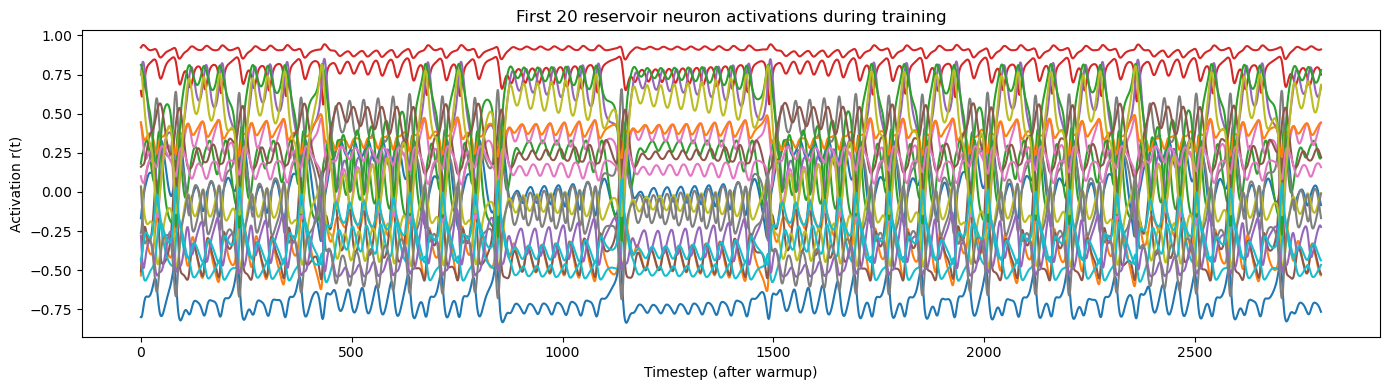

In [5]:
# Design matrix: rows = [1 bias | 3 input | N reservoir], cols = time
X  = np.zeros((1 + inSize + N,  trainLen - initLen))

# Target matrix: we want to predict the NEXT step (t + dt)
# Yt[:, k] = lorenz state at time initLen + k + 1
Yt = data_lorenz[initLen + 1 : trainLen + 1].T   # shape (3, trainLen-initLen)

# Run reservoir
r = np.zeros((N, 1))           # initial reservoir state = 0
for t in range(trainLen):
    u = data_lorenz[t].reshape(-1, 1)          # shape (3,1)
    bias_u = np.vstack([[1], u])               # shape (4,1) = [bias; x; y; z]
    r = (1 - a) * r + a * np.tanh(Win @ bias_u + W @ r)
    if t >= initLen:
        col = np.vstack([[1], u, r])[:, 0]    # shape (1+3+N,)
        X[:, t - initLen] = col

print(f"Design matrix X shape : {X.shape}")
print(f"Target matrix Yt shape: {Yt.shape}")

# Visualise some reservoir activations during training
plt.figure(figsize=(14, 4))
plt.plot(X[1 + inSize : 1 + inSize + 20, :].T)
plt.title("First 20 reservoir neuron activations during training")
plt.xlabel("Timestep (after warmup)")
plt.ylabel("Activation r(t)")
plt.tight_layout()
plt.show()

## A6 — Train the Readout Weights via Ridge Regression

We solve for `W_out` in:

$$W^{\text{out}} = Y_t X^T \left(X X^T + \lambda I\right)^{-1}$$

In practice we use `scipy.linalg.solve` which is more numerically stable than computing the explicit inverse.

W_out shape: (3, 304)


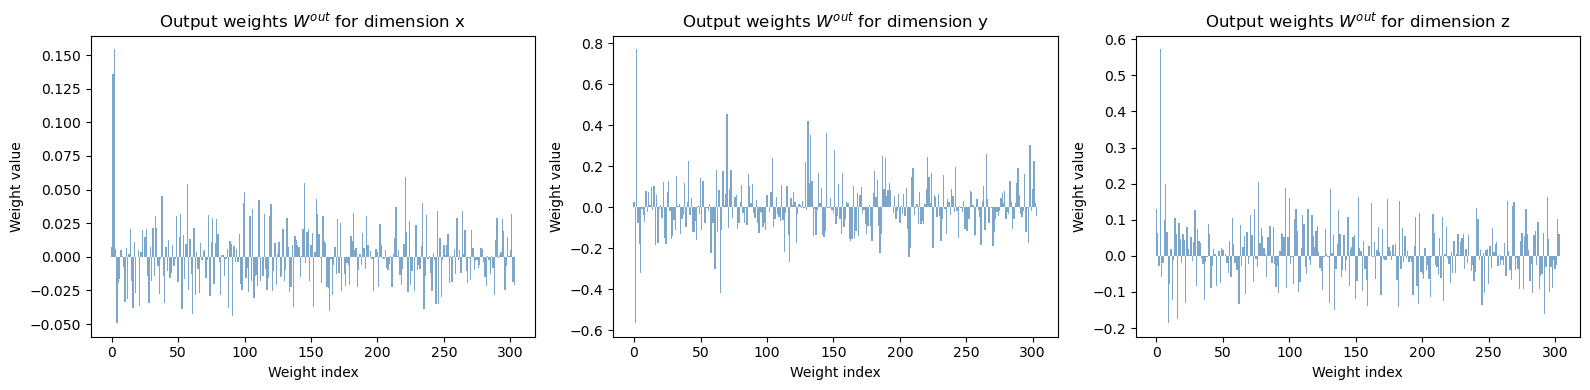

In [6]:
# Ridge regression: solve  (X X^T + λI) W_out^T = X Yt^T
A    = X @ X.T + reg * np.eye(1 + inSize + N)
B    = X @ Yt.T
Wout = linalg.solve(A, B).T          # shape (outSize=3, 1+inSize+N)

print(f"W_out shape: {Wout.shape}")

# Plot the readout weight distribution for each output neuron
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = ['x', 'y', 'z']
for i, ax in enumerate(axes):
    ax.bar(np.arange(Wout.shape[1]), Wout[i], width=1.0, color='steelblue', alpha=0.7)
    ax.set_title(f"Output weights $W^{{out}}$ for dimension {labels[i]}")
    ax.set_xlabel("Weight index")
    ax.set_ylabel("Weight value")
plt.tight_layout()
plt.show()

## A7 — Generative Mode: Autonomous Long-Term Prediction

After training, we switch to **generative (closed-loop) mode**:
- The reservoir's own output `ŷ(t)` is fed back as the next input `u(t+1)`
- No real data is used after the handover point `t₀ = trainLen`

A good reservoir should reproduce the **statistics and shape** of the Lorenz attractor, even if it diverges from the exact trajectory (which is expected for any chaotic system).

In [7]:
Y = np.zeros((outSize, testLen))
u = data_lorenz[trainLen].reshape(-1, 1)   # last known real input

for t in range(testLen):
    bias_u = np.vstack([[1], u])
    r      = (1 - a) * r + a * np.tanh(Win @ bias_u + W @ r)
    y      = Wout @ np.vstack([[1], u, r])  # linear readout
    Y[:, t] = y[:, 0]
    u = y                                   # ← GENERATIVE: feed output back as input
    # to switch to PREDICTIVE mode instead, use:
    # u = data_lorenz[trainLen + t + 1].reshape(-1, 1)

# ── MSE over first 500 test steps ────────────────────────────
errorLen = 500
target   = data_lorenz[trainLen + 1 : trainLen + errorLen + 1]   # (errorLen, 3)
pred     = Y[:, :errorLen].T                                      # (errorLen, 3)
mse      = np.mean((target - pred) ** 2)
mse_per  = np.mean((target - pred) ** 2, axis=0)
print(f"MSE (first {errorLen} steps):")
print(f"  Overall : {mse:.6f}")
print(f"  x       : {mse_per[0]:.6f}")
print(f"  y       : {mse_per[1]:.6f}")
print(f"  z       : {mse_per[2]:.6f}")

MSE (first 500 steps):
  Overall : 0.044497
  x       : 0.067180
  y       : 0.054419
  z       : 0.011893


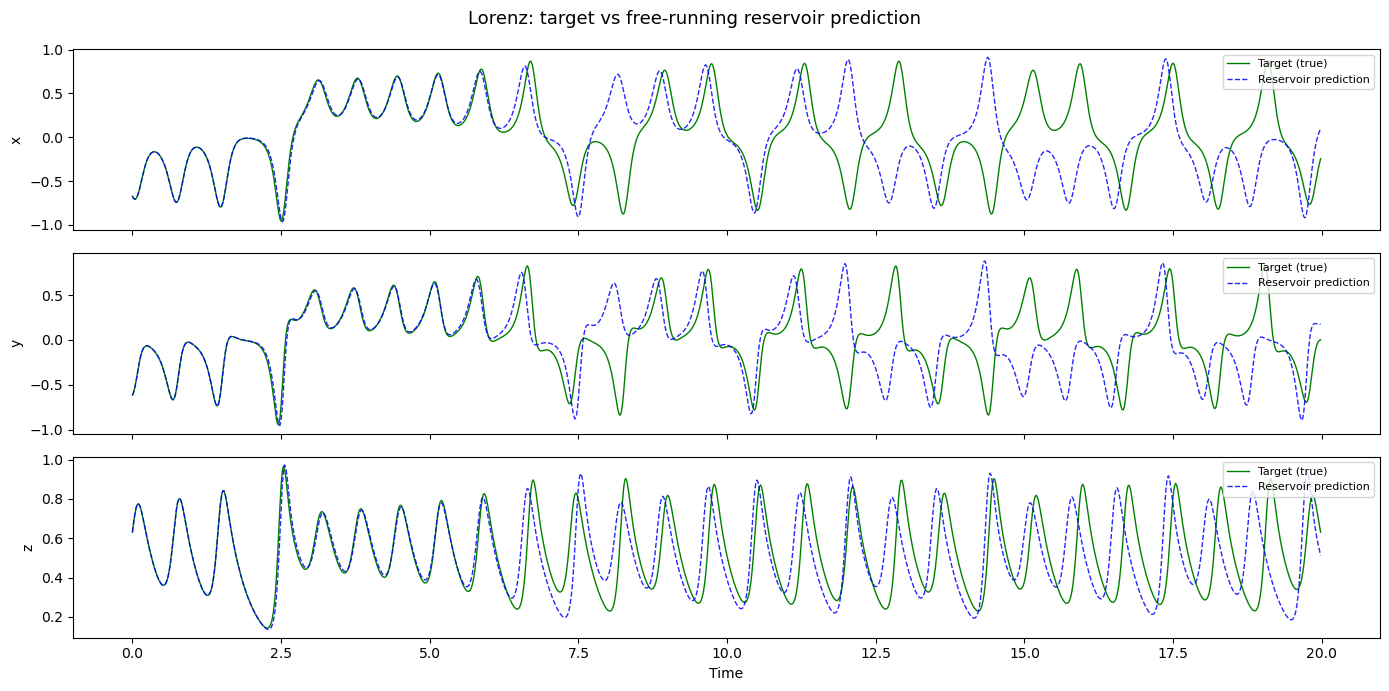

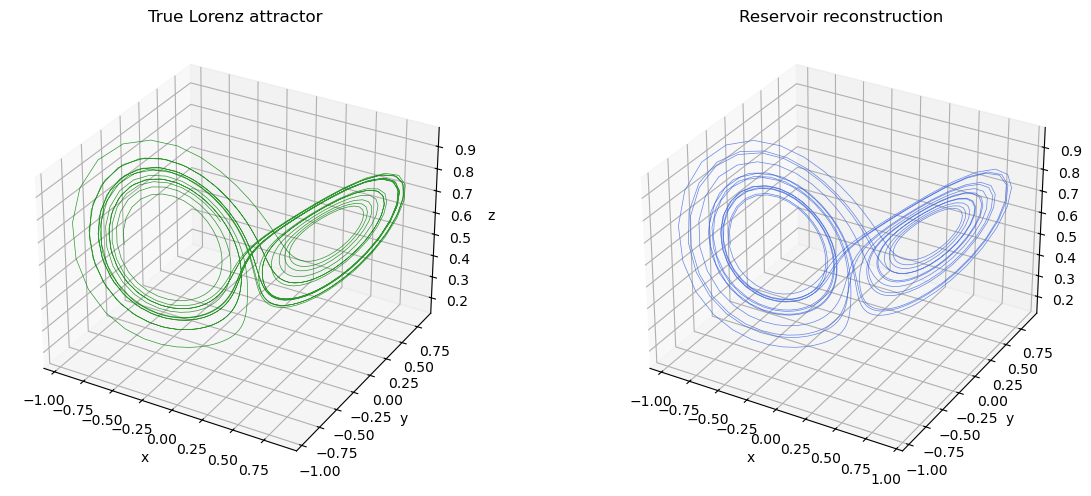

In [8]:
# ── Time-series comparison: target vs predicted ───────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
labels = ['x', 'y', 'z']
t_axis = np.arange(testLen) * dt
for i, ax in enumerate(axes):
    ax.plot(t_axis, data_lorenz[trainLen + 1 : trainLen + testLen + 1, i],
            'g', lw=1.0, label='Target (true)')
    ax.plot(t_axis, Y[i],
            'b--', lw=1.0, label='Reservoir prediction', alpha=0.85)
    ax.set_ylabel(labels[i])
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel("Time")
fig.suptitle("Lorenz: target vs free-running reservoir prediction", fontsize=13)
plt.tight_layout()
plt.show()

# ── 3D attractor comparison ───────────────────────────────────
fig = plt.figure(figsize=(13, 5))
for idx, (traj, title, col) in enumerate([
    (data_lorenz[trainLen + 1 : trainLen + testLen + 1], "True Lorenz attractor",    'green'),
    (Y.T,                                                "Reservoir reconstruction", 'royalblue')
]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    ax.plot(*traj.T, lw=0.5, color=col, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout()
plt.show()